# 📘 Notebook pédagogique : Méthode de Monte Carlo

---

## 1. Introduction : qu’est-ce qu’une simulation de Monte Carlo ?

La **méthode de Monte Carlo** est une technique qui consiste à **estimer l'intégrale d'une variable en grande dimension** en utilisant du **hasard**. Calculer une intégrale en grande dimension est compliqué, parce que les points sont tous très éloignés les uns des autres. Par exemple, si on veut séparer le segment [0, 1] en dx, on peut le découper en dix sous-segments [0 ; 0,1] , [0,1 ; 0,2] ... On aura donc besoin d'estimer 10 fois f (en 0, 0.1, 0.2 ...) pour quadriller tout l'espace. Ainsi, si on veut calculer l'intégrale de f par la méthode des rectangles, on dira que l'intégrale de f(x).dx sur le segment[0,1] vaut approximativement la somme  f(0) * (0.1 - 0.0) + f(0.1) * (0.2 - 0.1) + f(0.2) * (0.3 - 0.2) ... qui est une somme de rectangles de hauteur f(xi) et de largeur (dx). (Puis on peut faire tendre le nombre de rectangles vers l'infini pour avoir une bonne estimation de l'intégrale).
Si on veut faire la même chose sur une grille de dimension 2, il faudra cette fois $$10^2$$ points pour quadriller l'intervalle [1 ; 1] x [0 ; 1] comme un damier. Et si x est une image de dimension n, dont les pixels peuvent prendre 10 valeurs chacun, il faut $$10^n$$ points d'estimation de l'intégrale, ce qui devient vite énorme (il y a 10**80 atomes dans l'univers). 

Ainsi, l'idée des simulations de Monte Carlo est que, si x est une image avec 1 million de pixels, au lieu de calculer l'intégrale d'une fonction de cette image (intégrale de f(x)dx) en prenant la somme des f(x)dx où dx suit un pas régulier, on tire des x au hasard et on calcule la valeur de f(x) en ces points. En d'autres termes, la valeur de dx est aléatoire (on peut l'écrire p(x)*dx où dx est déterministe, d'où l'idée d'espérande parce que l'intégrale de f(x)*p(x)*dx est la formule d'une espérance). Le dx représente ici un pas infinitésimal dans l'espace des images, c'est à dire un tout petit changement de l'image (une oreille de chat un peu plus étirée par ex), et concerne tous les pixels de l'image. 

Ça peut sembler être une mauvaise idée de prendre des dx aléatoires, mais en fait, dans des espaces de grande dimension (par exemple, si x représente tous les pixels d'une image ou 200 pas de temps d'une série temporelle), l'espace est mieux quadrillé par une grille aléatoire que par un maillage uniforme. Cela vient de propriétés mathématiques contre intuitives d'alignement en grande dimension. 


L’idée fondamentale est la suivante :

>  Une espérance (ou une intégrale) peut être approchée par une moyenne sur des tirages aléatoires.

Mathématiquement, si l’on veut calculer :

$$
\mathbb{E}[f(X)] = \int f(x) p(x) dx
$$

alors on peut approximer, grâce à la loi des grands nombres :

$$
\mathbb{E}[f(X)] \approx \frac{1}{N} \sum_{i=1}^N f(x_i)
$$

où les $$(x_i)$$ sont tirés aléatoirement selon la loi p(x)


=== Méthode des rectangles en 1D ===
Nombre de rectangles : 10
Largeur dx = 0.1
Approximation = 0.2850000000000001
Valeur exacte = 0.3333333333333333
Erreur = 0.04833333333333323


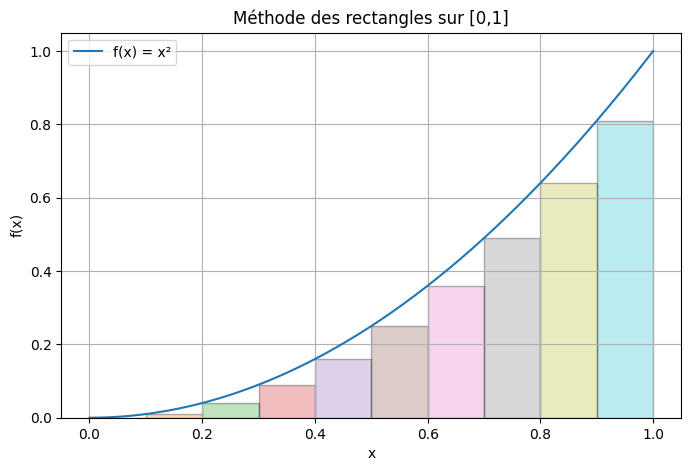


=== Maillage en 2D ===
Points par axe : 10
Nombre total de points : 100


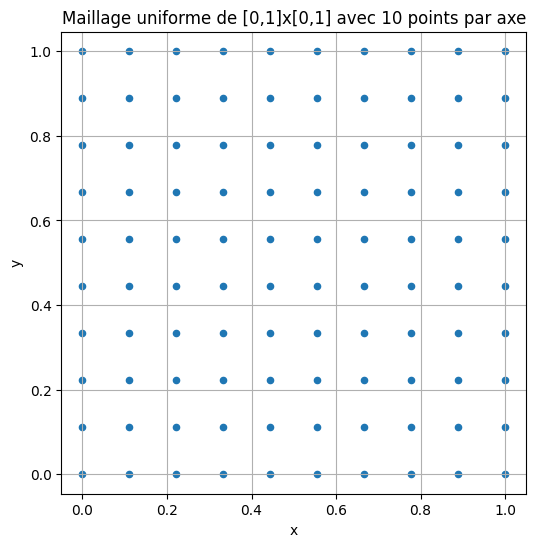


=== Explosion combinatoire ===
Dimension  1 : 10^1 = 10 points
Dimension  2 : 10^2 = 100 points
Dimension  3 : 10^3 = 1000 points
Dimension  4 : 10^4 = 10000 points
Dimension  5 : 10^5 = 100000 points
Dimension  6 : 10^6 = 1000000 points
Dimension  7 : 10^7 = 10000000 points
Dimension  8 : 10^8 = 100000000 points
Dimension  9 : 10^9 = 1000000000 points
Dimension 10 : 10^10 = 10000000000 points


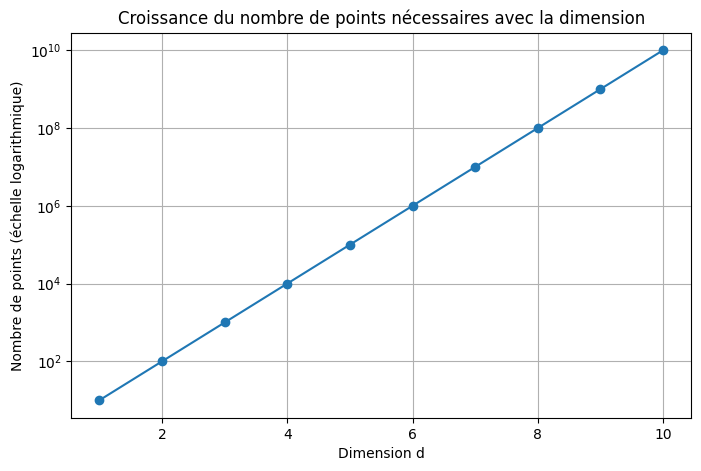

In [3]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1) METHODE DES RECTANGLES EN DIMENSION 1
# ============================================================

def f(x):
    """Fonction à intégrer."""
    return x**2


def rectangle_method(f, a, b, n):
    """
    Approxime l'intégrale de f sur [a,b] par la méthode des rectangles à gauche.
    
    Paramètres
    ----------
    f : fonction
        Fonction à intégrer.
    a, b : float
        Bornes de l'intervalle.
    n : int
        Nombre de sous-intervalles.
        
    Retour
    ------
    approx : float
        Approximation de l'intégrale.
    x_left : ndarray
        Points de gauche des rectangles.
    dx : float
        Largeur des rectangles.
    """
    dx = (b - a) / n
    x_left = np.linspace(a, b - dx, n)   # points gauches
    approx = np.sum(f(x_left) * dx)
    return approx, x_left, dx


# Exemple sur [0,1]
a, b = 0, 1
n = 10

approx, x_left, dx = rectangle_method(f, a, b, n)
exact = 1 / 3  # intégrale exacte de x^2 sur [0,1]

print("=== Méthode des rectangles en 1D ===")
print(f"Nombre de rectangles : {n}")
print(f"Largeur dx = {dx}")
print(f"Approximation = {approx}")
print(f"Valeur exacte = {exact}")
print(f"Erreur = {abs(approx - exact)}")


# Visualisation
x_plot = np.linspace(a, b, 400)
y_plot = f(x_plot)

plt.figure(figsize=(8, 5))
plt.plot(x_plot, y_plot, label="f(x) = x²")

for xi in x_left:
    plt.bar(xi, f(xi), width=dx, align='edge', alpha=0.3, edgecolor='black')

plt.title("Méthode des rectangles sur [0,1]")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# 2) MAILLAGE UNIFORME EN DIMENSION 2
# ============================================================

def create_2d_grid(n_per_axis):
    """
    Crée un maillage uniforme de [0,1]x[0,1] avec n_per_axis points par axe.
    
    Retour
    ------
    X, Y : ndarrays
        Coordonnées du maillage 2D.
    """
    x = np.linspace(0, 1, n_per_axis)
    y = np.linspace(0, 1, n_per_axis)
    X, Y = np.meshgrid(x, y)
    return X, Y


n_per_axis = 10
X, Y = create_2d_grid(n_per_axis)

print("\n=== Maillage en 2D ===")
print(f"Points par axe : {n_per_axis}")
print(f"Nombre total de points : {n_per_axis**2}")


# Visualisation du maillage
plt.figure(figsize=(6, 6))
plt.scatter(X, Y, s=20)
plt.title(f"Maillage uniforme de [0,1]x[0,1] avec {n_per_axis} points par axe")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.axis("equal")
plt.show()


# ============================================================
# 3) EXPLOSION DU NOMBRE DE POINTS AVEC LA DIMENSION
# ============================================================

def number_of_grid_points(k, d):
    """
    Nombre de points nécessaires si l'on prend k valeurs possibles
    par dimension dans un espace de dimension d.
    
    Exemple : k=10, d=2 -> 10^2 = 100 points.
    """
    return k**d


k = 10

print("\n=== Explosion combinatoire ===")
for d in range(1, 11):
    print(f"Dimension {d:2d} : {k}^{d} = {number_of_grid_points(k, d)} points")


# Visualisation de la croissance
dimensions = np.arange(1, 11)
points_needed = [number_of_grid_points(k, d) for d in dimensions]

plt.figure(figsize=(8, 5))
plt.plot(dimensions, points_needed, marker='o')
plt.yscale("log")
plt.title("Croissance du nombre de points nécessaires avec la dimension")
plt.xlabel("Dimension d")
plt.ylabel("Nombre de points (échelle logarithmique)")
plt.grid(True)
plt.show()

# 2. Exemple simple : billes sur une cible ###
  
**Problème** : On se place dans le cas d'un x à deux dimensions (ses coordonnées dans un plan). On veut estimer le nombre pi. On sait que pi est proportionnel à l'aire d'un disque de rayon 1. 

Interprétation mathématique On veut calculer : $$ \int_{[0,1]^2} \mathbf{1}_{\text{disque}}(x,y) dx dy $$  C’est l'**intégrale de la fonction indicatrice du disque**. 

Alors au lieu de prendre une intégrale sur le disque, ce qui nécessite des calculs compliqués, on lance des billes au hasard dans un carré, et on regarde combien tombent dans un disque inscrit. Cela permet d’estimer l'aire du disque et donc π.
Ainsi, la grille sur laquelle on évalue la fonction indicatrice est ici l'ensemble des positions atteintes par les billes, et elle est aléatoire. 

Remarque : ici, l'aléatoire n'apporte rien comparé à une intégrale déterministe, mais ça illustre la méthode.

In [7]:
import numpy as np
import matplotlib.pyplot as plt

N = 10000
x = np.random.rand(N)
y = np.random.rand(N)

# disque centré en (0.5, 0.5)
inside = (x-0.5)**2 + (y-0.5)**2 <= 0.25

# estimation
area_estimate = inside.mean()
print("Aire estimée:", area_estimate)


Aire estimée: 0.784


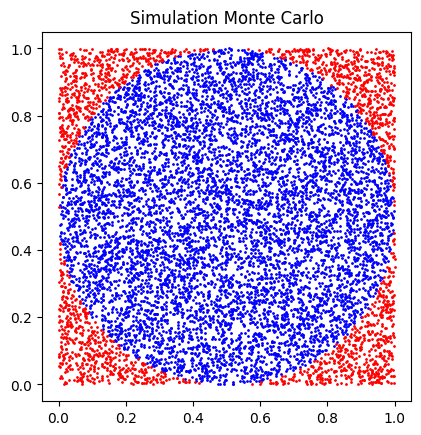

In [8]:
plt.scatter(x[inside], y[inside], color='blue', s=1)
plt.scatter(x[~inside], y[~inside], color='red', s=1)
plt.gca().set_aspect('equal')
plt.title("Simulation Monte Carlo")
plt.show()


### 🧠 Interprétation

Chaque bille correspond à un point aléatoire.

-> La proportion de billes dans le disque ≈ aire du disque.

Donc on approxime une intégrale par :

$$
\frac{1}{N} \sum \mathbf{1}_{\text{disque}}(x_i)
$$

---

## 3. Monte Carlo = intégrale sur une grille aléatoire

Dans une méthode classique (grille régulière, méthode des rectangles de Riemann) :

* on découpe l’espace en points réguliers
* coût exponentiel en dimension

Monte Carlo :

* on échantillonne **au hasard** (c'est à dire qu'on tire des x au hasard et on évalue f(x) en ces points aléatoires)
* coût indépendant de la dimension (en ordre de grandeur)

👉 C’est pour cela que Monte Carlo est **très puissant en grande dimension**.

---

### ⚠️ Pourquoi les méthodes classiques échouent en grande dimension ?

Si on prend 10 points par dimension :

* en 2D → 100 points
* en 10D → 10¹⁰ points ❌

Monte Carlo :

* 10 000 points restent 10 000 points, quelle que soit la dimension

👉 La convergence est plus lente, mais **elle ne dépend pas de la dimension**.

Reformulation plus rigoureuse de ce que GPT a dit: l'estimateur de Monte Carlo est non biaisé (son erreur de biais ne dépend pas de la dimension), mais il a de la variance qui décroît en 1/sqrt(n) où n = dim(x). 

---

## 4. Application en finance : modélisation d’un prix

---

### 📈 Modèle : marche aléatoire

On modélise un prix (X_t) avec :

$$
X_{t+1} = X_t + \epsilon_t
$$

avec $$\epsilon_t \sim \mathcal{N}(0, 100)$$

---

### 💻 Données observées


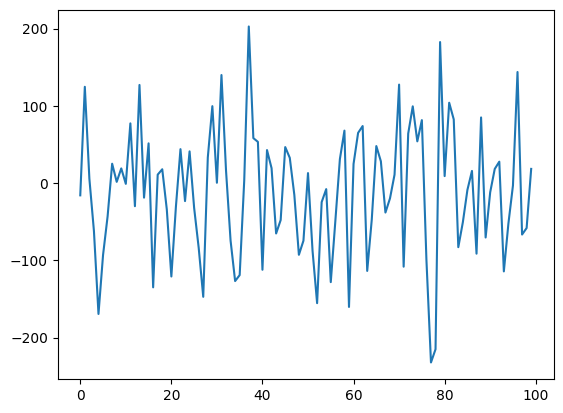

In [11]:

import numpy as np
import matplotlib.pyplot as plt

X = np.random.normal(0,100,100)
plt.plot(X)




## 5. Hypothèse de Markov

Dans un modèle général :

$$
P(X_t | X_1, ..., X_{t-1})
$$

👉 dépend de tout le passé

Dans un modèle de Markov :

$$
P(X_t | X_{t-1})
$$

👉 dépend seulement du présent

---

## 6. Objectif : pricer une option

On veut calculer :

$$
\mathbb{E}[X_{200}]
$$ c'est à dire la valeur moyenne de l'option dans 100 pas de temps supplémentaires (en vrai GPT s'est trompé, c'est une espérance conditionnelle  E[X_200 I X_100] )

ou plus généralement :

$$[
\mathbb{E}[g(X_{200})]
]$$

👉 c’est une **intégrale sur tous les chemins possibles**.

-> ça veut dire qu'on prend tous les chemins qui vont de 100 à 200, on regarde quel X_200 ils donnent, et on prend l'espérance des X_200 sur tous les chemins possibles, soit intégrale( X_200 * p(X_200 a cette valeur) ) = intégrale (X_200 * p(X_200  I x_199) * p(X_199)) etc et donc en fait c'est une intégrale de dimension 100.  

---

## 7. Dimension du problème

Un chemin complet est :

$$[
(X_{101}, X_{102}, ..., X_{200})
]$$

👉 dimension = 100

Donc :

👉 intégrale en dimension 100 ❌ impossible classiquement

👉 Monte Carlo = solution naturelle

---

Donc ici, au lieu de prendre l'intégrale des X_200*p(X_200), on prend la moyenne empirique de la valeur de X_200 après des simulations tirées aléatoirement. On fait la même chose qu'avec les billes tout à l'heure, mais au lieu de reagarder combien de billes tombent dans le cercle, on regarde combien de chemins de prix tombent dans chaque intervalle de valeur possible, pour en déduire la position moyenne de l'endroit d'arrivée d'un chemin après 200 pas de temps. 

On prend donc la moyenne sur toutes nos simulations (qui représentent toutes les arrivées de chemins possibles) de leur valeur finale. 

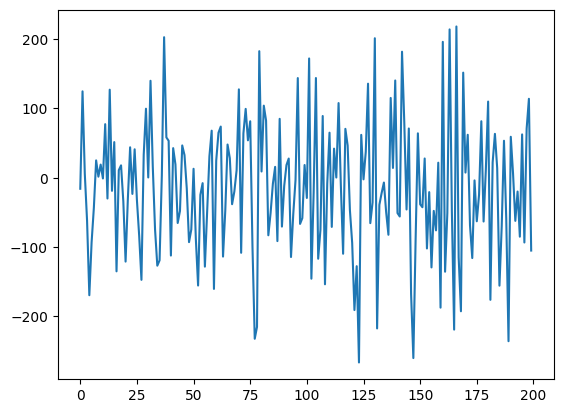

In [14]:
### Modèle correct

B = np.append(X,np.random.normal(0, 100,100))
plt.plot(B)


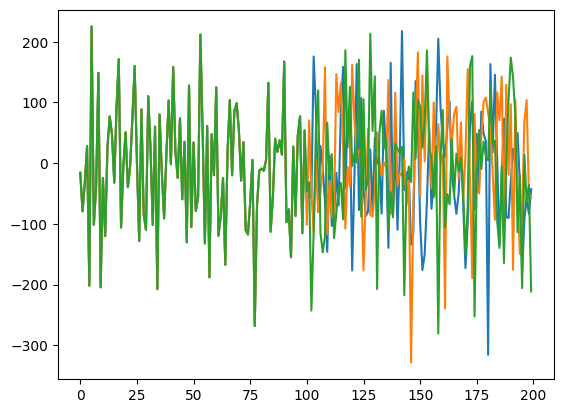

In [15]:
## 9. Simulations Monte Carlo

A = np.random.normal(0,100,100)
W1 = np.append(A,np.random.normal(0, 100,100))
W2 = np.append(A,np.random.normal(0, 100,100))
W3 = np.append(A,np.random.normal(0, 100,100))

plt.plot(W1)
plt.plot(W2)
plt.plot(W3)


## 10. Estimation

On approxime :

$$
\mathbb{E}[X_{200}] \approx \frac{1}{N} \sum X_{200}^{(i)}
$$

👉 moyenne des valeurs finales simulées


---

## 11. Interprétation : intégrale sur les chemins

En réalité, on ne calcule pas une intégrale classique, mais une intégrale sur des **trajectoires complètes** :

$$
\int g(\text{chemin}) , dP(\text{chemin})
$$

👉 Chaque "chemin" correspond à une trajectoire possible du processus

👉 L’espace des chemins est de **très grande dimension** (voire infinie) 

Monte Carlo consiste alors à :

> tirer des chemins aléatoires, puis moyenner les valeurs de (g)

---

## 12. Lien avec les intégrales de Feynman

En mécanique quantique, on rencontre des intégrales de la forme :

$$
\int \mathcal{D}x(t); e^{i S[x]/\hbar}
$$

👉 où :

* (x(t)) est une trajectoire (un chemin)
* (S[x]) est l’action associée au chemin
* (\mathcal{D}x(t)) signifie qu’on intègre sur **tous les chemins possibles**

---

### 🧠 Interprétation

👉 Une quantité physique est obtenue en sommant les contributions de **toutes les trajectoires possibles**.

Cela ressemble fortement à :

$$
\int g(\text{chemin}) , dP(\text{chemin})
$$

mais avec une différence importante :

* en Monte Carlo → on a une **probabilité**
* en mécanique quantique → on a un **poids oscillant** (e^{iS/\hbar})

-> À chaque instant, une particule est dans une superposition d'état, où chaque état correspond à un chemin (par ex la trajectoire de la particule au cours du temps). En physique classique, on n'observe que les états les plus probables, car la décroissance entre les chemins un peu moins probables est très rapide (elles interfèrent négativement entre elles). 
Mais du coup on a quand même besoin de calculer des intégrales en très grande dimension, d'où l'intérêt des simulations de Monte Carlo.

---

### 🎲 Version utilisable numériquement

En pratique, on travaille souvent avec une version transformée :

[
\int \mathcal{D}x(t); e^{- S[x]}
]

👉 qui ressemble à une **distribution de probabilité**

➡️ Cela permet d’utiliser des méthodes de type Monte Carlo.

---

## 🎯 Conclusion

La méthode de Monte Carlo :

* transforme une intégrale difficile en moyenne
* évite la malédiction de la dimension
* s’applique même à des espaces très complexes (comme les espaces de chemins)

---

👉 Idée clé :

> Une intégrale peut être vue comme une moyenne sur des tirages aléatoires

---

💡 Intuition finale :

* billes → intégrale en dimension 2
* finance → intégrale en dimension 100
* physique quantique → intégrale sur un espace de chemins (dimension infinie)

👉 même idée fondamentale, mais sur des espaces de plus en plus riches
